0 0 [-0.09809877 -0.58903611]
0 1 [ 0.33667051 -0.31219238]
0 2 [-0.82024119 -0.22424296]
0 3 [-0.29720839  0.11423652]
0 4 [-0.56852789 -0.18324369]
0 5 [-0.66056109  0.37321781]

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ]
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533]
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119]
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635]

[[ 0  0  0 50]
 [ 0  0  0 50]
 [ 0  0  0 50]
 [ 0  0  0 50]]


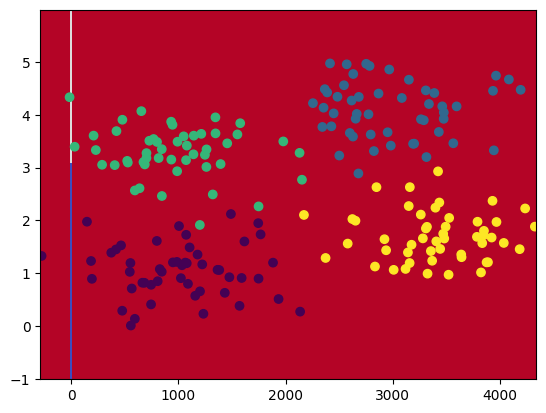

In [35]:
from sklearn.datasets import make_blobs, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import time

blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, Y = make_blobs(n_samples=200,
                          centers=blob_centers,
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000


clf = MLPClassifier(hidden_layer_sizes=(6, ), random_state=1)
clf.fit(X, Y)

for i in range(len(clf.coefs_)):
    for j in range(clf.coefs_[i].shape[1]):
        print(i, j, clf.coefs_[i][:,j])
    print()

def plot(clf, X, Y):
    print(confusion_matrix(Y, clf.predict(X)))

    X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
    X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
    X0_grid, X1_grid = np.meshgrid(X0, X1)

    y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
    plt.pcolormesh(X0_grid, X1_grid, y_predict, cmap='coolwarm')

    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.show()

plot(clf, X, Y)

[[22  0 11 17]
 [ 0 38  0 12]
 [ 0  3 45  2]
 [ 0  5  0 45]]


C:\Users\Artem\PycharmProjects\MLProject\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


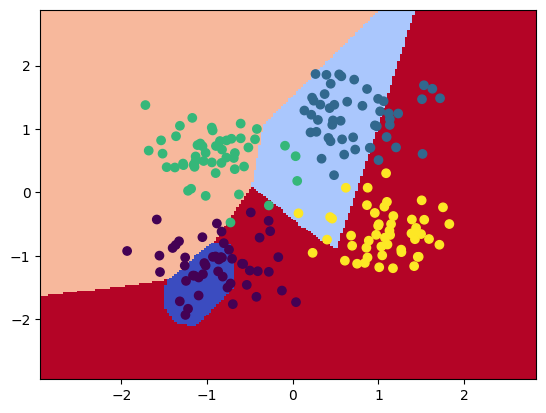

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf.fit(X_scaled, Y)

plot(clf, X_scaled, Y)


Iteration 1, loss = 1.55772482
Iteration 2, loss = 1.55299983
Iteration 3, loss = 1.54829381
Iteration 4, loss = 1.54360706
Iteration 5, loss = 1.53894010
Iteration 6, loss = 1.53430411
Iteration 7, loss = 1.52969980
Iteration 8, loss = 1.52511575
Iteration 9, loss = 1.52055201
Iteration 10, loss = 1.51602274
Iteration 11, loss = 1.51154009
Iteration 12, loss = 1.50707954
Iteration 13, loss = 1.50263954
Iteration 14, loss = 1.49822103
Iteration 15, loss = 1.49382404
Iteration 16, loss = 1.48945117
Iteration 17, loss = 1.48511055
Iteration 18, loss = 1.48079387
Iteration 19, loss = 1.47649973
Iteration 20, loss = 1.47222850
Iteration 21, loss = 1.46797950
Iteration 22, loss = 1.46375268
Iteration 23, loss = 1.45955297
Iteration 24, loss = 1.45538335
Iteration 25, loss = 1.45124561
Iteration 26, loss = 1.44713022
Iteration 27, loss = 1.44303725
Iteration 28, loss = 1.43896663
Iteration 29, loss = 1.43491796
Iteration 30, loss = 1.43089070
Iteration 31, loss = 1.42688916
Iteration 32, los

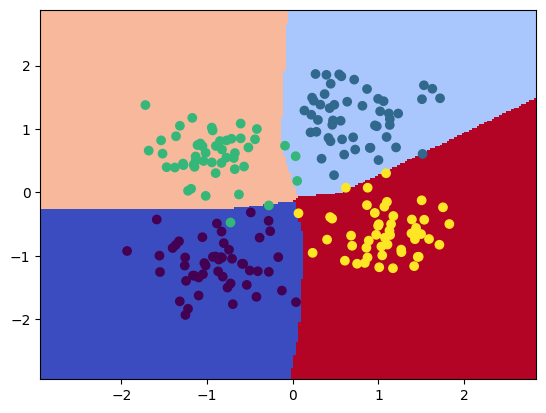

In [4]:
clf = MLPClassifier(hidden_layer_sizes=(6, ), random_state=1, max_iter=10000, verbose=True)
clf.fit(X_scaled, Y)

plot(clf, X_scaled, Y)

[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  1 48  0]
 [ 0  0  0 50]]


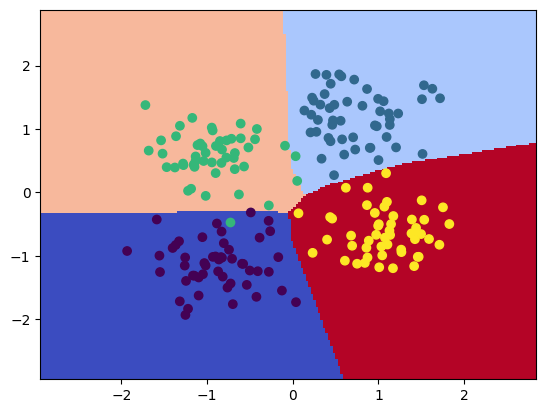

In [5]:
clf = (MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000))
clf.fit(X_scaled, Y)

plot(clf, X_scaled, Y)

Время  0.02984786033630371
[[50  0  0  0]
 [50  0  0  0]
 [50  0  0  0]
 [50  0  0  0]]


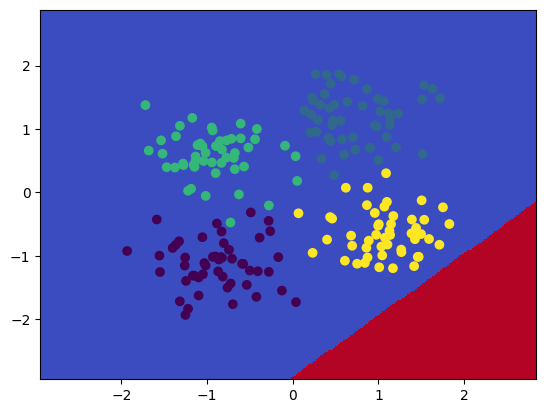

Время  0.2914724349975586
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 1  1  1 47]]


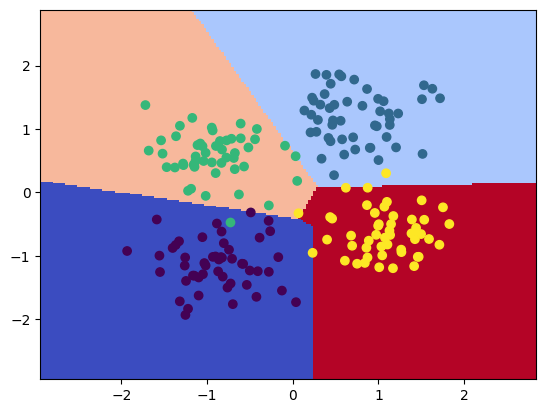

Время  0.1456451416015625
[[50  0  0  0]
 [ 0 50  0  0]
 [ 2  1 47  0]
 [ 0  1  0 49]]


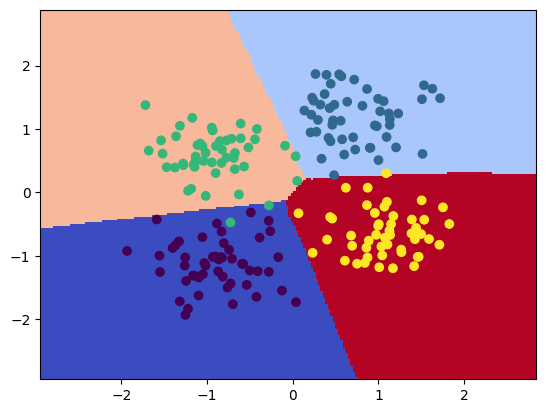

Время  0.12041831016540527
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


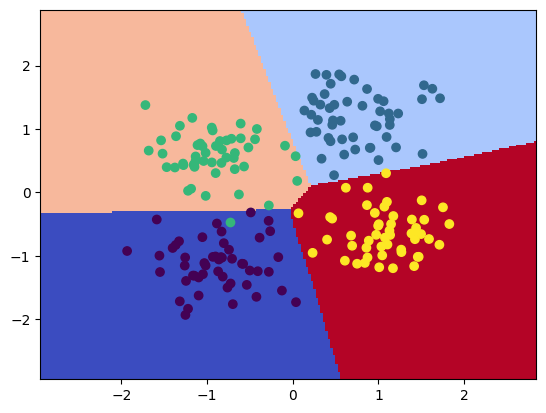

In [16]:
for n in [1, 2, 10, 100]:
    clf = (MLPClassifier(hidden_layer_sizes=(n,), max_iter=10_000))
    start = time.time()
    clf.fit(X_scaled, Y)
    end = time.time() - start
    print('Время ', end)

    plot(clf, X_scaled, Y)

Время  0.5202620029449463
[[50  0  0  0]
 [ 0 50  0  0]
 [ 1  0 49  0]
 [ 0  0  0 50]]


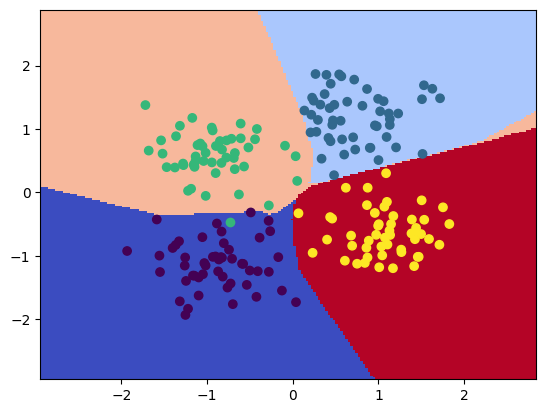

Веса нейронов
0 0 [ 0.63547578 -0.68405818]
0 1 [-0.85352206 -1.00639051]
0 2 [-0.26489493  1.16944085]
0 3 [-0.69488843 -0.71573392]
0 4 [-0.27125653  0.46882775]
0 5 [0.99487387 0.23977229]

1 0 [ 0.96610493  0.78829232 -0.89971975  0.83481811 -0.07746044 -0.29960148]
1 1 [ 0.77751575  0.40793347 -0.06238821  0.75205804 -0.87690616  0.20114288]
1 2 [-0.31415777  0.59519299 -0.66653628  0.53958203  0.03890712 -0.42446867]
1 3 [-0.20001506  0.74743716  0.01528973  0.19775886  0.04840679 -1.07370553]
1 4 [-0.24577286 -0.33439868  0.73398321  0.14529627 -0.20727573  0.91477162]
1 5 [ 0.30282423 -0.5576745  -0.07561074 -0.00176508 -0.16657868  0.44390756]

2 0 [-8.59092339e-03 -5.10083221e-06  9.45099068e-09 -3.73631793e-03
  3.23261214e-05  2.86143440e-02]
2 1 [-0.31600651  0.76173844  0.30065868 -1.00144776  0.55620785 -0.32720538]
2 2 [ 0.31146406 -0.50101897  0.66684439  1.21349986 -0.17865387  0.38168062]
2 3 [ 0.96371976 -0.02853973  0.31738725  1.37613118  0.14256126  0.73650553]
2

In [17]:
clf = (MLPClassifier(hidden_layer_sizes=(6, 6, 6, 6, 6, 6, 6, 6, 6, 6), max_iter=10_000))
start = time.time()
clf.fit(X_scaled, Y)
end = time.time() - start
print('Время ', end)

plot(clf, X_scaled, Y)

print('Веса нейронов')
for i in range(len(clf.coefs_)):
    for j in range(clf.coefs_[i].shape[1]):
        print(i, j, clf.coefs_[i][:,j])
    print()

print('Векторы смещения')
for i in range(len(clf.intercepts_)):
    for j in range(len(clf.intercepts_[i])):
        print(i, j, clf.intercepts_[i][j])
    print()

In [44]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data = fetch_olivetti_faces()
X = data.data
Y = data.target
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.25, random_state=42, stratify=Y
)

clf = (MLPClassifier(hidden_layer_sizes=(100, ), max_iter=10_000))
start = time.time()
clf.fit(X_train , y_train)
end = time.time() - start

print(metrics.accuracy_score(y_test, clf.predict(X_test)))
print(confusion_matrix(y_test, clf.predict(X_test )))

0.97
[[2 0 0 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 0 3 0]
 [0 0 0 ... 0 0 2]]


In [60]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = (MLPRegressor(hidden_layer_sizes=(100, ), max_iter=10_000))
start = time.time()
clf.fit(X_train, y_train)
end = time.time() - start

print("R²:", metrics.r2_score(y_test, clf.predict(X_test)))
print("MAE:", metrics.mean_absolute_error(y_test, clf.predict(X_test)))

R²: 0.7771685951183303
MAE: 0.3713651015167968
